In [ ]:
# usando python 3.11.9

In [2]:
import pandas as pd
import numpy as np

In [24]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [4]:
df = pd.read_csv('exchange_rates.csv')

In [12]:
df

,Unnamed: 0,Country/Currency,currency,value,date
0,0,Australia Dollar,AUD,1.581627,17/12/2021
1,1,Great Britain Pound,GBP,0.851619,17/12/2021
2,2,Euro,EUR,1.000000,17/12/2021
3,3,Japan Yen,JPY,128.301759,17/12/2021
4,4,Switzerland Franc,CHF,1.041015,17/12/2021
...,...,...,...,...,...
192832,192832,Euro,EUR,1.000000,27/10/2025
192833,192833,Japan Yen,JPY,178.104056,27/10/2025
192834,192834,Switzerland Franc,CHF,0.925907,27/10/2025
192835,192835,USA Dollar,USD,1.163075,27/10/2025


In [ ]:
# Conversão da coluna de data e definição como índice
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

C:\Users\Beatriz\AppData\Local\Temp\ipykernel_8808\3208583366.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'])


,Unnamed: 0,Country/Currency,currency,value
date,,,,
2021-12-17,0,Australia Dollar,AUD,1.581627
2021-12-17,1,Great Britain Pound,GBP,0.851619
2021-12-17,2,Euro,EUR,1.000000
2021-12-17,3,Japan Yen,JPY,128.301759
2021-12-17,4,Switzerland Franc,CHF,1.041015
...,...,...,...,...
2025-10-27,192832,Euro,EUR,1.000000
2025-10-27,192833,Japan Yen,JPY,178.104056
2025-10-27,192834,Switzerland Franc,CHF,0.925907


In [15]:
df = df.drop('Unnamed: 0', axis=1)

In [31]:
ts = df[df['currency'] == 'USD']

In [35]:
ts['value']

date
2021-12-17    1.132548
2021-12-18    1.123810
2021-12-19    1.123810
2021-12-20    1.124405
2021-12-21    1.128382
                ...   
2025-10-23    1.160827
2025-10-24    1.161713
2025-10-25    1.162650
2025-10-26    1.162650
2025-10-27    1.163075
Name: value, Length: 1409, dtype: float64

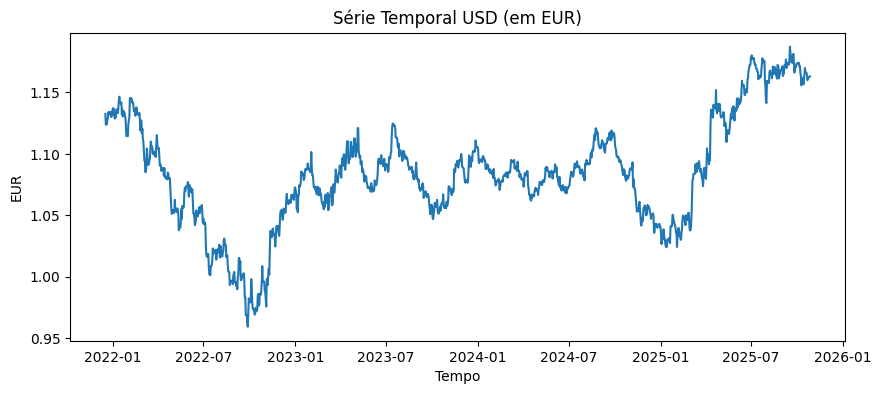

In [36]:
plt.figure(figsize=(10, 4))
plt.plot(ts['value'])
plt.title('Série Temporal USD (em EUR)')
plt.xlabel('Tempo')
plt.ylabel('EUR')
plt.show()

In [37]:
ts_missing_block = ts.copy()

data_inicio_remocao = '2023-01-01'
data_fim_remocao = '2023-07-31'

# Removendo (substituindo por NaN) o bloco de dados
ts_missing_block.loc[data_inicio_remocao:data_fim_remocao] = np.nan

print(f"Número de observações removidas em bloco: {ts_missing_block.isna().sum()}")

Número de observações removidas em bloco: Country/Currency    212
currency            212
value               212
dtype: int64


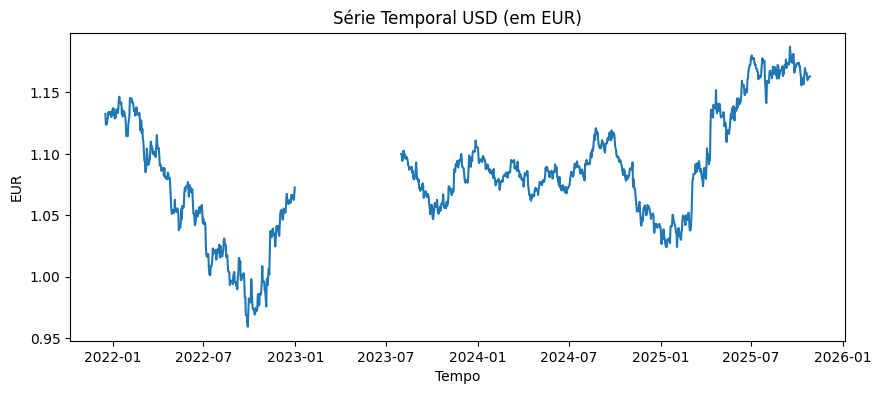

In [38]:
plt.figure(figsize=(10, 4))
plt.plot(ts_missing_block['value'])
plt.title('Série Temporal USD (em EUR)')
plt.xlabel('Tempo')
plt.ylabel('EUR')
plt.show()